# Tool catalog: browser media foundation

Run this notebook cell by cell in a disposable JupyterLab project with its live Python kernel at the server root. The generated red PNG is an actual local input, not a camera image. Each browser call returns a receipt immediately; wait for the media row to finish and run its inspection cell on a later turn. The AI questions use the selected ChatGPT connection and ask for real tool calls. They do not request device access.


## Make an exact local media reference

In [1]:
from pathlib import Path
from uuid import uuid4
import hashlib
from PIL import Image
from nbinlineai.tools import browser_capabilities, operation_status, cancel_operation, save_media, release_media

server_root = Path.cwd().resolve()  # Start JupyterLab with this disposable project as its server root.
source = server_root / f'browser-media-source-{uuid4().hex[:8]}.png'
Image.new('RGB', (2, 2), 'red').save(source)
ai_save_to = f'browser-media-ai-{uuid4().hex[:8]}.png'
source_ref = {'path': source.name, 'sha256': hashlib.sha256(source.read_bytes()).hexdigest()}
source_ref

{'path': 'browser-media-source-f7d5ca9b.png',
 'sha256': 'de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c'}

## browser_capabilities

In [2]:
from nbinlineai.tools import browser_capabilities
capabilities = browser_capabilities()
capabilities

BrowserReceipt(operation_id=None, status='running')

In [3]:
print('Capability receipt:', capabilities.status, capabilities.error)
if capabilities.status == 'completed':
    print('Browser capabilities:', capabilities.result)


Capability receipt: completed None
Browser capabilities: {'secure_context': True, 'permissions': {'camera': 'granted', 'microphone': 'granted'}, 'file_media_supported': True, 'operations': {'browser_capabilities': True, 'operation_status': True, 'cancel_operation': True, 'save_media': True, 'release_media': True, 'list_media_sources': True, 'start_camera': True, 'start_microphone': True, 'capture_camera': True, 'stop_source': True, 'start_recording': True, 'pause_recording': True, 'resume_recording': True, 'stop_recording': True, 'record_camera': True, 'record_microphone': True, 'read_audio_levels': True, 'setup_share': True, 'start_share': True, 'capture_screen': True, 'capture_tool': True, 'stop_share': True, 'list_outputs': True, 'read_output': True, 'export_output': True, 'read_notebook_view': True, 'read_selection': True, 'list_canvases': True, 'capture_canvas': True, 'export_canvas': True, 'start_canvas': True, 'capture_notebook_region': True, 'choose_file': True, 'open_media': T

Use &`browser_capabilities` now. Report the actual file-save capability and one concrete limit from its result; give the arguments you used. Do not request camera, microphone, or screen access.


Called `browser_capabilities` with `{}`. File-based media is supported (`file_media_supported: true`), and `save_media` is available. One limit: server media files can be at most 268,435,456 bytes (256 MiB).

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `browser_capabilities` | completed | {} | {"operation_id":"-QLuPK2A_oo8m2N_pskSX1wXRBDd-oKt","secure_context":true,"permissions":{"camera":"granted","microphone":"granted"},"file_media_supported":true,"operations":{"browser_capabilities":true,"operation_status":true,"cancel_operation":true,"save_media":true,"release_media":true,"list_media_sources":true,"start_camera":true,"start_microphone":true,"capture_camera":true,"stop_source":true,"start_recording":true,"pause_recording":true,"resume_recording":true,"stop_recording":true,"record_camera":true,"record_microphone":true,"read_audio_levels":true,"setup_share":true,"start_share":true,"capture_screen":true,"capture_tool":true,"stop_share":true,"list_outputs":true,"read_output":true," |


## save_media

In [4]:
from nbinlineai.tools import save_media
saved = save_media(source_ref, save_to='auto')
saved

BrowserReceipt(operation_id=None, status='running')

In [5]:
print('Save receipt:', saved.status, saved.error)
if saved.status == 'completed':
    print('Saved descriptor:', {key: saved.media.get(key) for key in ('media_id', 'path', 'sha256', 'mime_type')})
    print('File exists:', (server_root / saved.media['path']).is_file())
if saved.status == 'completed':
    saved_operation_id = saved.operation_id
    saved_media_id = saved.media['media_id']


Save receipt: completed None
Saved descriptor: {'media_id': '521d7912245a115d1882b99c3276308b', 'path': 'media/capture-41d0f03d55f26c85.png', 'sha256': 'de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c', 'mime_type': 'image/png'}
File exists: True


Use &`save_media` on the exact PNG in $`source_ref`, setting `save_to` to $`ai_save_to`. Report the immediate operation ID/state only. The later status question will confirm the saved path and hash.


Operation ID: `i-NB82PhcJtTLOt1Y5u9AfRHNVW4vlip`; state: `completed`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `save_media` | completed | {"media":{"path":"browser-media-source-f7d5ca9b.png","sha256":"de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c"},"save_to":"browser-media-ai-375ba9e8.png"} | {"operation_id":"i-NB82PhcJtTLOt1Y5u9AfRHNVW4vlip","status":"completed","media":{"media_id":"ec29c1fc34ba3872a4ee51aa1a52c31d","mime_type":"image/png","bytes":73,"sha256":"de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c","expires_at":1790667499.514066,"path":"browser-media-ai-375ba9e8.png"}} |


After the AI save media row completes, use &`operation_status` on its exact operation ID. Report actual state, generated path, SHA-256, and managed media ID only if completed; otherwise stop and retry this status question later.


State: `completed`. Path: `browser-media-ai-375ba9e8.png`. SHA-256: `de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c`. Managed media ID: `ec29c1fc34ba3872a4ee51aa1a52c31d`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"i-NB82PhcJtTLOt1Y5u9AfRHNVW4vlip"} | {"operation_id":"i-NB82PhcJtTLOt1Y5u9AfRHNVW4vlip","status":"completed","media":{"media_id":"ec29c1fc34ba3872a4ee51aa1a52c31d","mime_type":"image/png","bytes":73,"sha256":"de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c","expires_at":1790667499.514066,"path":"browser-media-ai-375ba9e8.png"}} |


## operation_status

In [6]:
from nbinlineai.tools import operation_status
assert saved.status == 'completed', 'Wait for the save receipt, then rerun this cell.'
lookup = operation_status(saved.operation_id)
lookup

BrowserReceipt(operation_id=None, status='running')

In [7]:
print('Status lookup:', lookup.status, lookup.error)
if lookup.status == 'completed':
    print('Original operation snapshot:', lookup.result)


Status lookup: completed None
Original operation snapshot: {'operation_id': 'nd9jKBwlf9mNmjcsU7eTH0MktpK4znFL', 'status': 'completed', 'media': {'media_id': '521d7912245a115d1882b99c3276308b', 'mime_type': 'image/png', 'bytes': 73, 'sha256': 'de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c', 'expires_at': 1790667490.667226, 'path': 'media/capture-41d0f03d55f26c85.png'}}


Use &`operation_status` with operation ID $`saved_operation_id` for the completed direct save. Report its actual state and the ID you looked up.


Looked up operation `nd9jKBwlf9mNmjcsU7eTH0MktpK4znFL`; its state is `completed`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"nd9jKBwlf9mNmjcsU7eTH0MktpK4znFL"} | {"operation_id":"nd9jKBwlf9mNmjcsU7eTH0MktpK4znFL","status":"completed","media":{"media_id":"521d7912245a115d1882b99c3276308b","mime_type":"image/png","bytes":73,"sha256":"de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c","expires_at":1790667490.667226,"path":"media/capture-41d0f03d55f26c85.png"}} |


## cancel_operation

In [8]:
from nbinlineai.tools import cancel_operation
cancelled = cancel_operation(saved.operation_id)
cancelled

BrowserReceipt(operation_id=None, status='running')

In [9]:
print('Cancel after completed save:', cancelled.status, cancelled.error)
if cancelled.status == 'completed':
    print('Saved file still exists:', (server_root / saved.media['path']).is_file())


Cancel after completed save: completed None
Saved file still exists: True


Use &`cancel_operation` with operation ID $`saved_operation_id` after that save completed. Report the actual response and whether the saved file remains; do not say this deletes a file.


`cancel_operation` returned `completed` for `nd9jKBwlf9mNmjcsU7eTH0MktpK4znFL` and still included the saved media path, `media/capture-41d0f03d55f26c85.png`. Cancellation did not delete the saved file.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `cancel_operation` | completed | {"operation_id":"nd9jKBwlf9mNmjcsU7eTH0MktpK4znFL"} | {"operation_id":"nd9jKBwlf9mNmjcsU7eTH0MktpK4znFL","status":"completed","media":{"media_id":"521d7912245a115d1882b99c3276308b","mime_type":"image/png","bytes":73,"sha256":"de33ddc09a0ba9b83128b6b59461e3be59299575eb68ccf2c03984b504f9fa9c","expires_at":1790667490.667226,"path":"media/capture-41d0f03d55f26c85.png"}} |


## release_media

In [10]:
picture = Image.open(server_root / saved.media['path'])
picture.load()
from nbinlineai.tools import release_media
released = release_media(saved.media['media_id'])
released

BrowserReceipt(operation_id=None, status='running')

Release receipt: completed None
Saved file still exists: True
Delivered Pillow image: (2, 2)


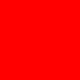

In [11]:
from IPython.display import display
print('Release receipt:', released.status, released.error)
print('Saved file still exists:', (server_root / saved.media['path']).is_file())
print('Delivered Pillow image:', picture.size)
display(picture.resize((80, 80)))


Use &`release_media` only on the managed media ID from the completed AI save status above. Report its immediate operation ID/state. This does not delete the saved file, which the cleanup cell removes by its exact generated path.


Operation ID: `0uvPMekNZv3WR5YLT0_JR39h0VHJd0S-`. Immediate result: `released: true`; no state field was returned.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `release_media` | completed | {"media_id":"ec29c1fc34ba3872a4ee51aa1a52c31d"} | {"operation_id":"0uvPMekNZv3WR5YLT0_JR39h0VHJd0S-","released":true} |


Use &`operation_status` on the preceding AI release operation ID after it completes. Report its actual terminal state; do not claim release from the initial snapshot.


The release operation’s terminal state is `completed`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"0uvPMekNZv3WR5YLT0_JR39h0VHJd0S-"} | {"operation_id":"0uvPMekNZv3WR5YLT0_JR39h0VHJd0S-","status":"completed","result":{"released":true}} |


In [12]:
saved_path = server_root / saved.media['path']
assert saved_path.exists() and picture.size == (2, 2)
saved_path.unlink()  # Remove only the exact file this example saved.
source.unlink(missing_ok=True)
(server_root / ai_save_to).unlink(missing_ok=True)  # Only the exact extra AI-save destination.
not saved_path.exists() and not source.exists()

True